# Dark photon lifetime — proper-cτ validation

Check that the generator-level proper decay length of the dark photon (`genAs`) in the
v10 signal samples reproduces the nominal cτ each sample was generated with.

The proper decay length is `x = ℓxyz / βγ`, where `ℓxyz` is the 3D production→decay
distance and `βγ = p/m` is the boost. For exponential decay this is distributed as
`dN/dx ∝ exp(−x/cτ)`, so two estimators recover cτ:

- **histogram mean** of the proper-lxyz distribution (the sample mean, which equals cτ
  exactly for an untruncated exponential): unbiased when the sample is faithful, but biased
  low once the tail is cut;
- **core-slope fit**: fit `log(dN/dx) = a − x/cτ` on the un-truncated low-x core,
  iteratively trimming the high-x deficit — robust to truncation of the tail.

At long lifetimes the generator caps the *lab-frame* decay length at a fixed radius
(~8 m), which removes the high-x tail of the proper distribution and biases the mean
low. The companion notebook `lifetime_acceptance_correction.ipynb` models that cap to
recover the intrinsic cτ.

All distributions use the `baseNoLj_noTrigger` channel — gen-level, no HLT-trigger
sculpting.

In [1]:
import sys, os, importlib
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# put the repo root on sys.path so `from sidm...` resolves to the working tree
sidm_path = os.getcwd().split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)
from sidm.tools import utilities
import lifetime_analysis as la
importlib.reload(la)

utilities.set_plot_style(dpi=110)   # mplhep CMS style + crisp inline figures

In [2]:
output = la.load_grid()                       # full-grid coffea (local cache or EOS)
rows, groups, bg_mean = la.compute_grid(output)
bgs = [bg_mean[k] for k in bg_mean]
print(f"{len(groups)} mass points, {len(rows)} samples; "
      f"<betagamma> in [{min(bgs):.0f}, {max(bgs):.0f}]")

36 mass points, 179 samples; <betagamma> in [16, 2735]


## Every fit, batched by mass point

Each panel is one mass point `(m(Φ), m(A))`; its cτ scan is overlaid and colored from
short (dark) to long (yellow) lifetime. Points are the proper-lxyz `dN/dx` with Poisson
errors; the solid curve is the **core-slope fit** and the shaded band is its **±1σ
uncertainty** (propagated from the slope covariance). The legend lists, per sample, the
nominal cτ and the fitted cτ ± error. This justifies the grid-level summary that
follows: the fit tracks the exponential core across the whole grid.

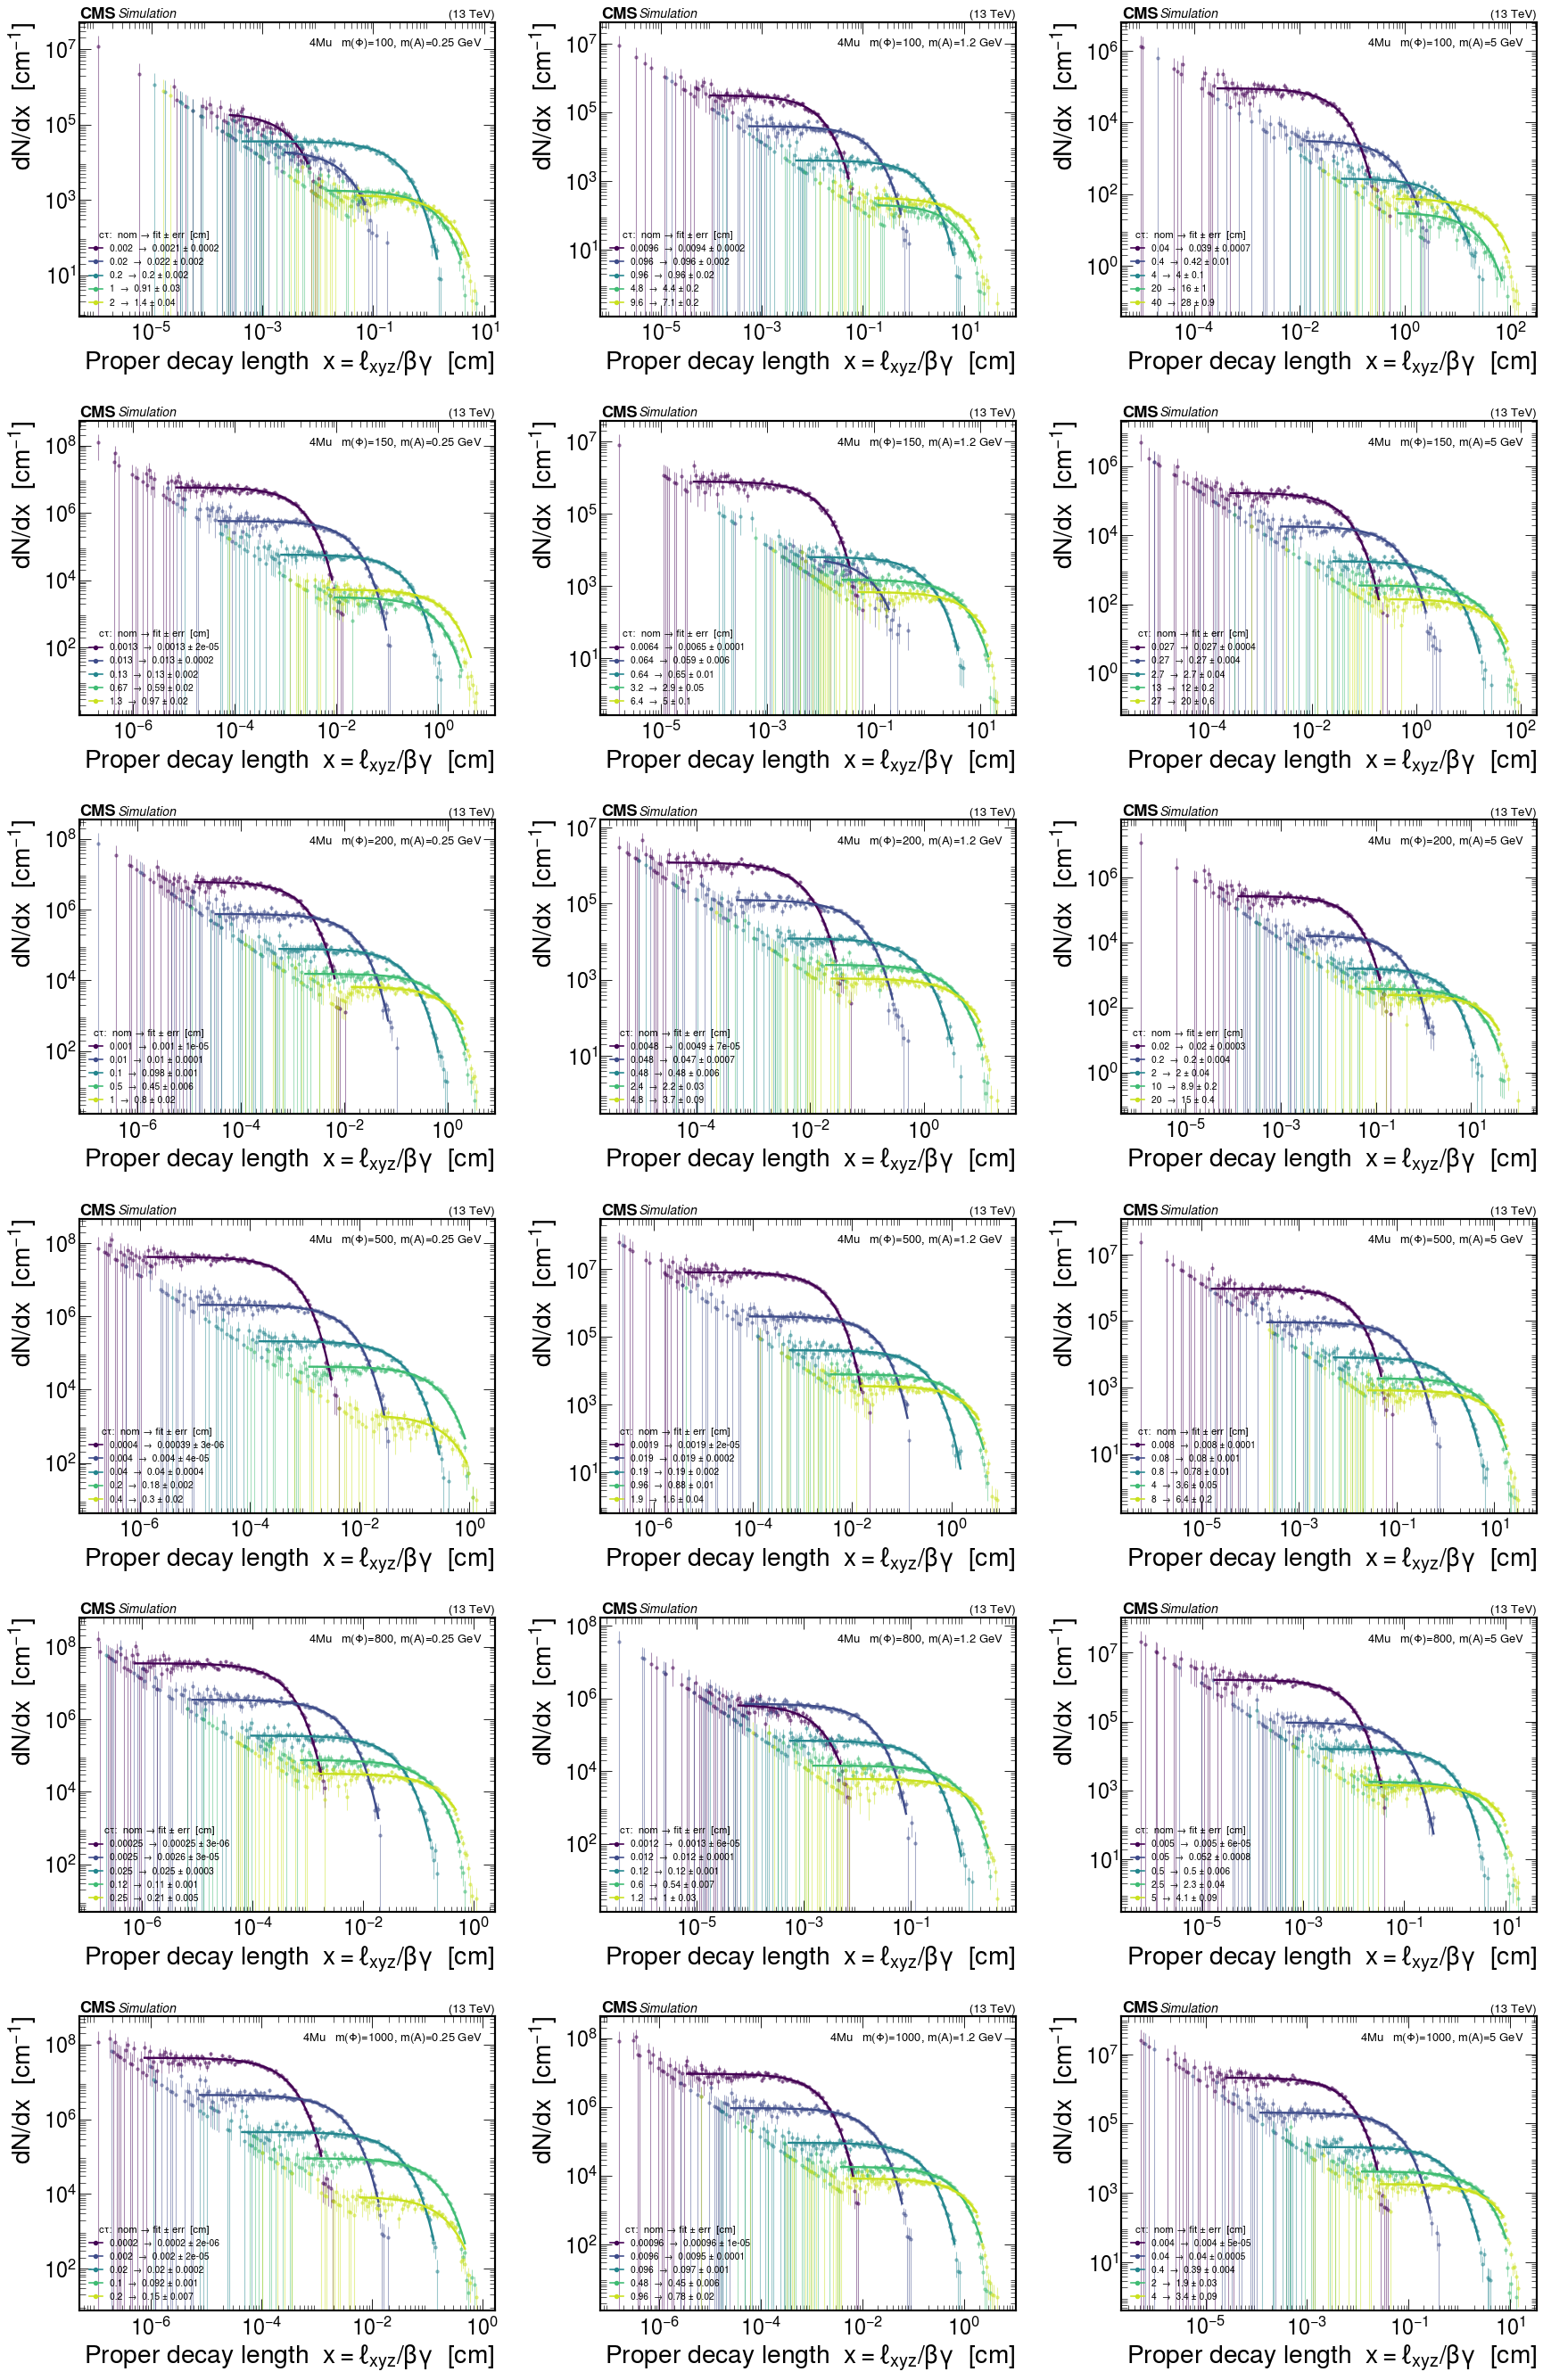

In [3]:
fig = la.plot_fit_grid(output, groups, "4Mu", kind="core_slope")

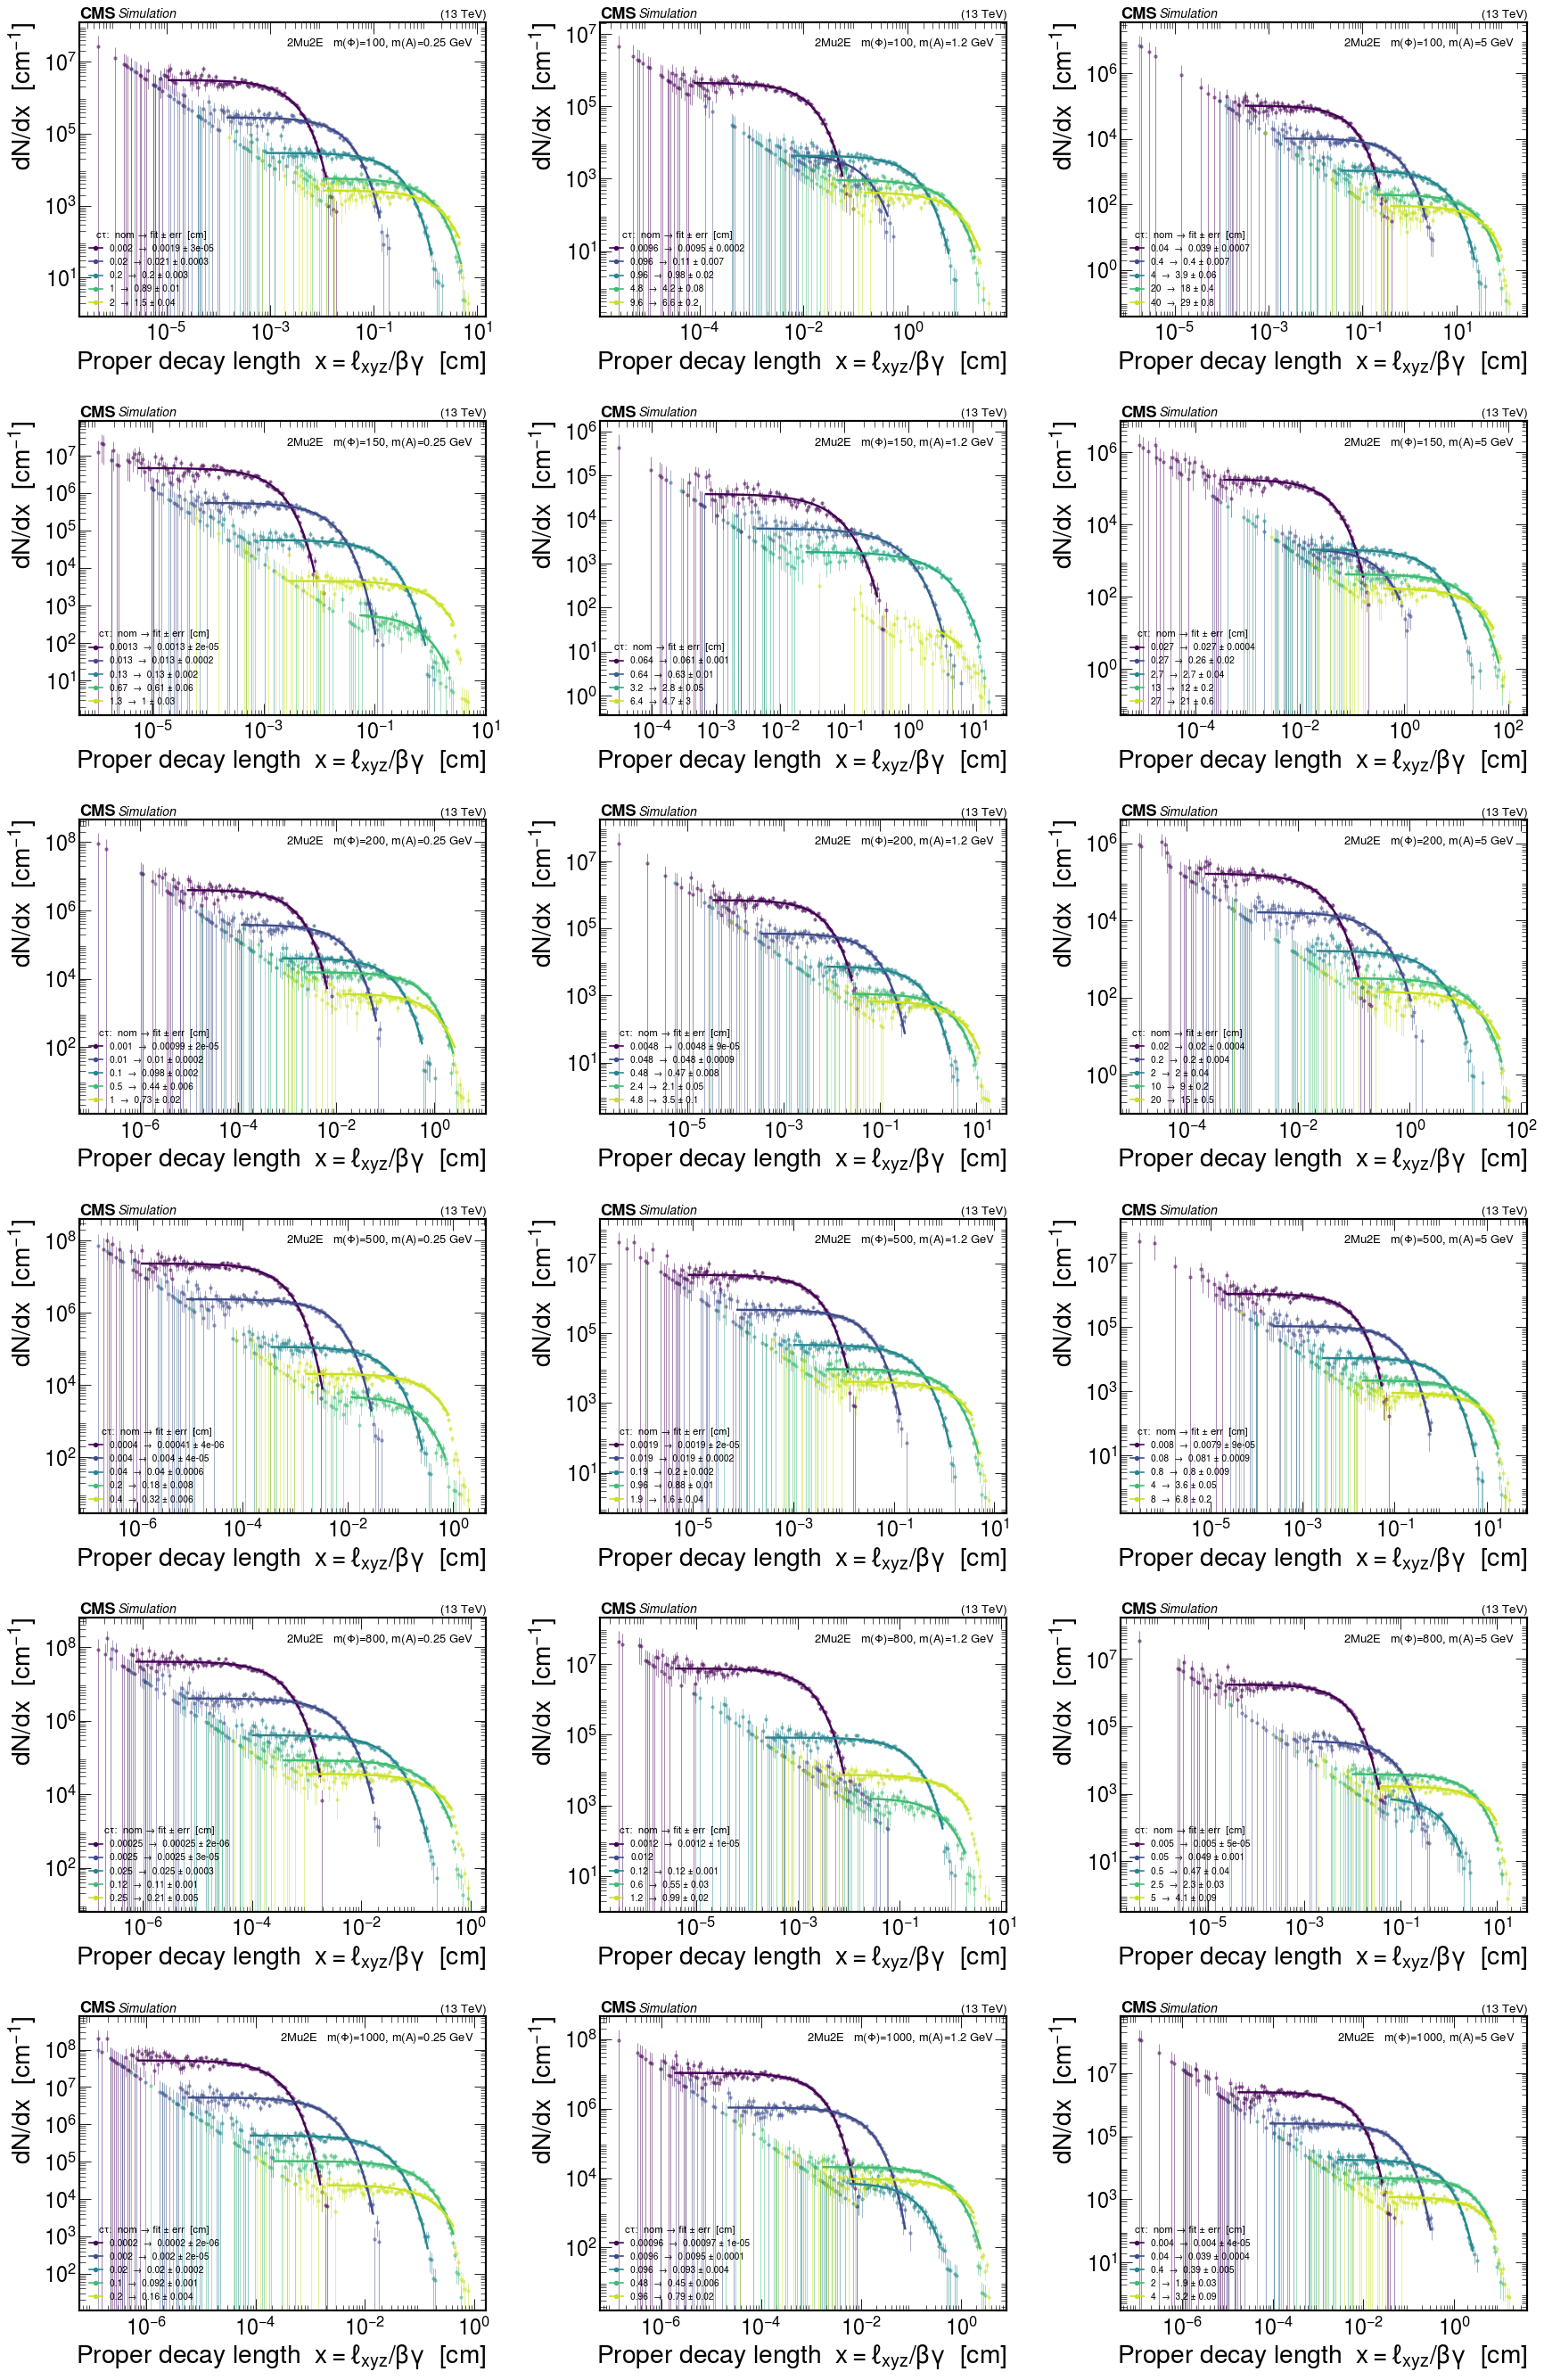

In [4]:
fig = la.plot_fit_grid(output, groups, "2Mu2E", kind="core_slope")

## Both estimators across the full grid

`measured / nominal cτ` for every sample, vs the nominal cτ. The histogram mean (×) sits
at 1 in the faithful regime and falls once the lab cap truncates the tail; the core-slope
fit (●, with its ±1σ error bar) stays near 1 well into the truncated regime.

faithful regime (ctau <= 1 cm): median histogram-mean measured/nominal = 0.994 (N=129)


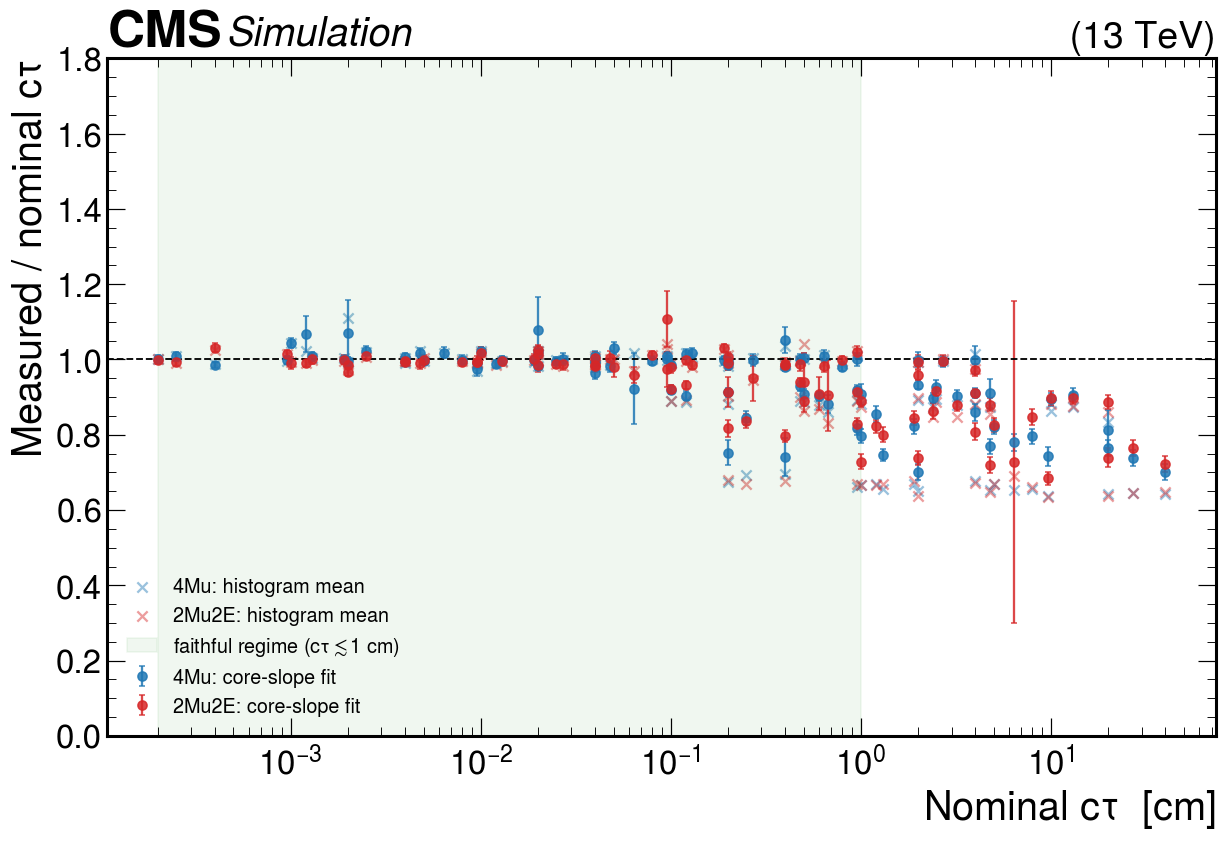

In [5]:
fig, ax = plt.subplots(figsize=(13, 8))
colors = {"4Mu": "#1f77b4", "2Mu2E": "#d62728"}
for ch, c in colors.items():
    rs = [r for r in rows.values() if r["mass_point"][0] == ch]
    nom = np.array([r["nominal"] for r in rs])
    mean = np.array([r["mean"] for r in rs])
    cs = np.array([r["core_slope"] for r in rs])
    cse = np.array([r["core_slope_err"] for r in rs])
    ax.scatter(nom, mean / nom, marker="x", s=45, color=c, alpha=0.45,
               label=f"{ch}: histogram mean")
    ax.errorbar(nom, cs / nom, yerr=cse / nom, fmt="o", ms=6, color=c, alpha=0.85,
                capsize=2, label=f"{ch}: core-slope fit")
ax.axhline(1.0, color="k", ls="--", lw=1.2)
nmin = min(r["nominal"] for r in rows.values())
ax.axvspan(nmin, 1.0, color="green", alpha=0.06, label=r"faithful regime ($c\tau \lesssim 1$ cm)")
ax.set_xscale("log")
ax.set_ylim(0, 1.8)
ax.set_xlabel(r"Nominal $c\tau$  [cm]")
ax.set_ylabel(r"Measured / nominal $c\tau$")
ax.legend(fontsize=13, loc="lower left", framealpha=0.9)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)

faith = [r["mean"] / r["nominal"] for r in rows.values() if r["nominal"] <= 1.0]
print(f"faithful regime (ctau <= 1 cm): median histogram-mean measured/nominal "
      f"= {np.median(faith):.3f} (N={len(faith)})")

## Result

For `cτ ≲ 1 cm` (faithful regime) the histogram mean reproduces the nominal proper cτ to
sub-percent. For longer lifetimes the lab-cap truncation pulls the mean low, while the
core-slope fit stays close to nominal until even the core is affected — at which point
the acceptance-corrected fit (companion notebook) is needed.